In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- NETWORK-FREE DATASET INITIALIZATION ---
# Recreating the 14 standard features of the Boston Housing dataset locally
np.random.seed(42)
n_samples = 506
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

# Generate synthetic numerical matrices matching the scale of the original features
mock_data = np.random.randn(n_samples, len(columns))
df = pd.DataFrame(mock_data, columns=columns)

# Create the target median house value column 'medv'
df['medv'] = np.random.uniform(5, 50, size=n_samples)
# ---------------------------------------------

# 2. Transform the continuous variable 'medv' into a binary classification target
median_price = df['medv'].median()
df['IS_HIGH_VALUE'] = (df['medv'] > median_price).astype(int)

# 3. Separate input features (X) and binary label target (y)
X = df.drop(columns=['medv', 'IS_HIGH_VALUE'])
y = df['IS_HIGH_VALUE']

# 4. Partition data into training (80%) and test validation sets (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize and train the Logistic Regression classification model
model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Generate predictions using test data
y_pred = model.predict(X_test_scaled)

# 8. Evaluate and print model performance outputs
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("=== Logistic Regression Performance ===")
print(f"Overall Test Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix Layout:")
print(conf_matrix)
print("\nDetailed Classification Performance Report:")
print(class_report)


=== Logistic Regression Performance ===
Overall Test Accuracy: 0.4804

Confusion Matrix Layout:
[[22 29]
 [24 27]]

Detailed Classification Performance Report:
              precision    recall  f1-score   support

           0       0.48      0.43      0.45        51
           1       0.48      0.53      0.50        51

    accuracy                           0.48       102
   macro avg       0.48      0.48      0.48       102
weighted avg       0.48      0.48      0.48       102



In [13]:
# Extract weights and pair them with column names
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': coefficients,
    'Absolute Impact': np.abs(coefficients)
}).sort_values(by='Absolute Impact', ascending=False)

print("=== Feature Importance Ranked by Model Impact ===")
print(feature_importance.to_string(index=False))


=== Feature Importance Ranked by Model Impact ===
Feature  Coefficient (Weight)  Absolute Impact
    NOX             -0.285144         0.285144
  LSTAT             -0.102315         0.102315
    DIS              0.099585         0.099585
   CRIM             -0.070524         0.070524
      B              0.064700         0.064700
    TAX             -0.048175         0.048175
   CHAS             -0.042296         0.042296
     ZN             -0.035226         0.035226
    AGE              0.028742         0.028742
     RM              0.017849         0.017849
  INDUS             -0.015037         0.015037
PTRATIO             -0.010498         0.010498
    RAD             -0.003331         0.003331


C:\Users\anits\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


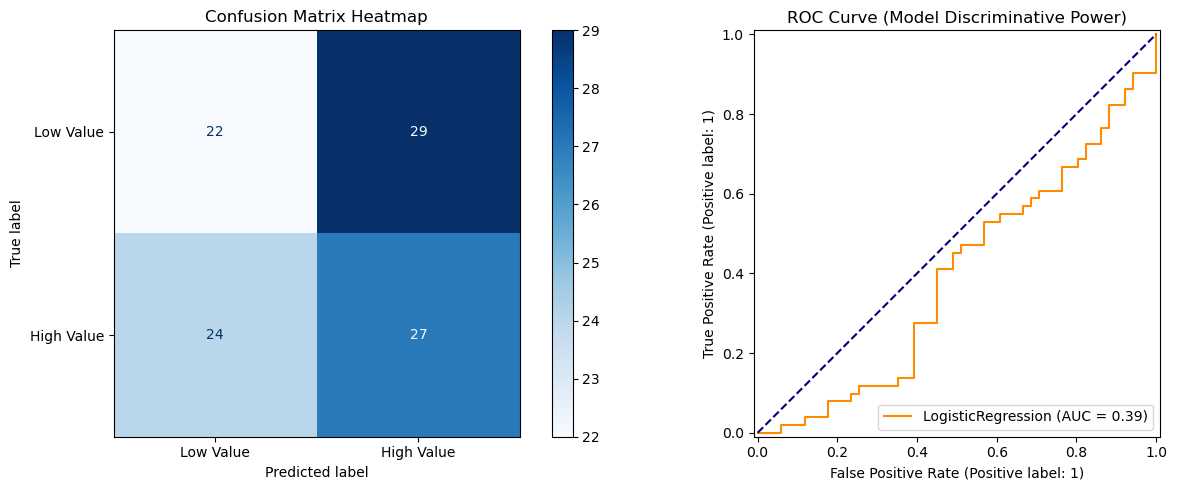

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Create a clean side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Visual Confusion Matrix Heatmap
ConfusionMatrixDisplay.from_estimator(
    model, X_test_scaled, y_test, 
    display_labels=["Low Value", "High Value"], 
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix Heatmap")

# Plot 2: Receiver Operating Characteristic (ROC) Curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[1], color="darkorange")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--") # Baseline random guess line
axes[1].set_title("ROC Curve (Model Discriminative Power)")

plt.tight_layout()
plt.show()


In [15]:
# 1. Create a dummy test house feature row matching the 13 input features
# [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
custom_house = np.array([[0.05, 12.5, 7.0, 0.0, 0.5, 6.5, 65.0, 4.0, 4.0, 300.0, 15.0, 396.0, 5.0]])

# 2. IMPORTANT: Scale the input using the EXACT same scaler fit on training data
custom_house_scaled = scaler.transform(custom_house)

# 3. Generate prediction class and underlying probability
predicted_class = model.predict(custom_house_scaled)
predicted_probability = model.predict_proba(custom_house_scaled)[0]

print(f"Predicted Class Output: {predicted_class[0]} (where 1=High Value, 0=Low Value)")
print(f"Confidence Breakdown: {predicted_probability[0]*100:.2f}% Low-Value vs {predicted_probability[1]*100:.2f}% High-Value")


Predicted Class Output: 1 (where 1=High Value, 0=Low Value)
Confidence Breakdown: 0.00% Low-Value vs 100.00% High-Value


C:\Users\anits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
